<a href="https://colab.research.google.com/github/alejandrosantanabonilla/dimer_search/blob/main/ColabTutorialWater.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
# Install condacolab
!pip install -q condacolab
import condacolab
condacolab.install()

⏬ Downloading https://github.com/jaimergp/miniforge/releases/download/24.11.2-1_colab/Miniforge3-colab-24.11.2-1_colab-Linux-x86_64.sh...
📦 Installing...
📌 Adjusting configuration...
🩹 Patching environment...
⏲ Done in 0:00:15
🔁 Restarting kernel...


In [2]:
import condacolab
condacolab.check()

# --- THE FIX ---
# Remove the file that forces a specific Python version
!rm -f /usr/local/conda-meta/pinned

# Now install tblite (and force python 3.11 just to be safe)
print("Installing tblite...")
!mamba install -c conda-forge tblite tblite-python python=3.11 -y

# Verify it works now
!tblite --version

✨🍰✨ Everything looks OK!
Installing tblite...

Looking for: ['tblite', 'tblite-python', 'python=3.11']

conda-forge/linux-64                                        Using cache
conda-forge/noarch                                          Using cache
Transaction

  Prefix: /usr/local

  Updating specs:

   - tblite
   - tblite-python
   - python=3.11
   - ca-certificates
   - certifi
   - openssl


  Package               Version  Build                Channel           Size
──────────────────────────────────────────────────────────────────────────────
  Install:
──────────────────────────────────────────────────────────────────────────────

  + libgfortran5         15.2.0  h68bc16d_16          conda-forge        2MB
  + libgfortran          15.2.0  h69a702a_16          conda-forge       27kB
  + libopenblas          0.3.30  pthreads_h94d23a6_4  conda-forge        6MB
  + toml-f                0.4.3  hb1d0f04_0           conda-forge      452kB
  + libblas              3.11.0  5_h4a7cf45_op

In [3]:
!git clone https://github.com/alejandrosantanabonilla/dimer_search.git
%cd dimer_search
!pip install .


fatal: destination path 'dimer_search' already exists and is not an empty directory.
/content/dimer_search
Processing /content/dimer_search
  Preparing metadata (setup.py) ... done
  Using cached parmed-4.3.0.tar.gz (20.2 MB)
  Preparing metadata (setup.py) ... done
  Using cached ase-3.26.0-py3-none-any.whl.metadata (4.1 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 3.7 MB/s eta 0:00:00
Using cached ase-3.26.0-py3-none-any.whl (2.9 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.9/35.9 MB 72.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.1/16.1 MB 114.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.4/36.4 MB 40.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 133.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 110.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 105.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 46.4 MB/s eta 0:00:

In [1]:
import dimer_search

INFO:dimer_search.utils:TBLite found and imported.


MHPlot found and imported.


In [2]:
import os
import shutil

# 1. Find where tblite is actually hiding
tblite_path = shutil.which("tblite")

if tblite_path:
    print(f"Found tblite at: {tblite_path}")

    # 2. Create a link to it in /usr/bin (the standard folder)
    # This ensures any program looking for 'tblite' will find it.
    !ln -sf {tblite_path} /usr/bin/tblite
    print("✅ Created shortcut in /usr/bin/tblite")
else:
    print("❌ Critical: tblite binary still not found. Did the conda install finish?")

Found tblite at: /usr/local/bin/tblite
✅ Created shortcut in /usr/bin/tblite


Running MoleculeProcessor Example...
Created initial system with 3 atoms and saved to 'mol.xyz'.

--- Test Case 2: With Relaxation (Fresh Start) ---
MoleculeProcessor initialized for input 'mol.xyz', output 'initial_assembly_for_relax.xyz'.

=== Starting Molecule Processing ===
Loading atoms from 'mol.xyz'...
Successfully loaded 3 atoms.
Aligning molecule and translating COM to origin...
Returning centered (but possibly not aligned) atoms.
Creating 2 rotated and translated copies...
Processing copy 1/2...
Processing copy 2/2...
Generated final assembly with 6 atoms.
Writing initial generated structure to 'initial_assembly_for_relax.xyz'...
Successfully wrote initial structure with 6 atoms.

--- Relaxation Requested (restart=False) ---

--- Starting relaxation from provided configuration (restart_calc=False) ---

Initiating relaxation using atoms from: Provided to relax function
Using TBLite parameters: {'method': 'GFN2-xTB', 'verbosity': 0, 'electronic_temperature': 5500.0, 'max_iterat

/usr/local/lib/python3.12/dist-packages/dimer_search/utils.py:141: FutureWarning: Please use atoms.calc = calc
  atoms_to_run.set_calculator(calculator)


3
{'bond-orders': array([[0.00000000e+00, 9.20561359e-01, 9.19369116e-01, 1.20797890e-08,
        2.31107156e-09, 3.07378894e-09],
       [9.20561359e-01, 0.00000000e+00, 2.83847591e-04, 3.07378894e-09,
        2.63898547e-10, 5.07800742e-09],
       [9.19369116e-01, 2.83847591e-04, 0.00000000e+00, 2.31107156e-09,
        5.49206319e-10, 2.63898547e-10],
       [1.20797890e-08, 3.07378894e-09, 2.31107156e-09, 0.00000000e+00,
        9.19369116e-01, 9.20561359e-01],
       [2.31107156e-09, 2.63898547e-10, 5.49206319e-10, 9.19369116e-01,
        0.00000000e+00, 2.83847591e-04],
       [3.07378894e-09, 5.07800742e-09, 2.63898547e-10, 9.20561359e-01,
        2.83847591e-04, 0.00000000e+00]])}
{'bond-orders': array([[0.00000000e+00, 9.20561359e-01, 9.19369116e-01, 1.20797890e-08,
        2.31107156e-09, 3.07378894e-09],
       [9.20561359e-01, 0.00000000e+00, 2.83847591e-04, 3.07378894e-09,
        2.63898547e-10, 5.07800742e-09],
       [9.19369116e-01, 2.83847591e-04, 0.00000000e+00, 2.31

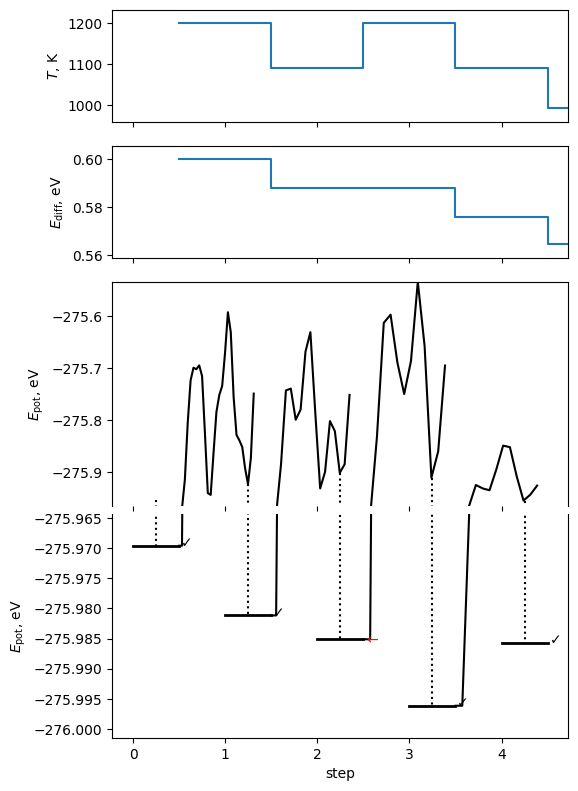

In [3]:
import numpy as np
from dimer_search import *
import glob
import os
from ase.build import molecule
from ase.io import write, read
from ase import Atoms

print("Running MoleculeProcessor Example...")

yaw = np.deg2rad([0, 180])
pitch = np.deg2rad([0, 180])
roll = np.deg2rad([45, 0])

translations = [
    [5.0, 0.0, 0.0],
    [0.0, 0.0, 0.0]
]

tblite_config = {
    "electronic_temperature": 5500.0,
    "max_iterations": 300,
}

mh_config = {
    "T0": 1200.0,
    "Ediff0": 0.6,
    "fmax": 0.1
}

# --- Create the initial system (Two Water Molecules) ---
# Create the first water molecule
water1 = molecule('H2O')

# Save the initial system to mol.xyz so the processor can read it
input_filename = "mol.xyz"
write(input_filename, water1)
print(f"Created initial system with {len(water1)} atoms and saved to '{input_filename}'.")

# --- Test Case 2: Process WITH relaxation (fresh start) ---
print("\n--- Test Case 2: With Relaxation (Fresh Start) ---")
# Clean up potential relaxation files from previous runs
for f in ['minima.traj', 'qn*.traj', 'hop.log', 'relax_run_*.xyz', 'relax_run_*.png']:
    for ff in glob.glob(f):
        if os.path.exists(ff): os.remove(ff)

# NOTE: If you get a "NameError: MoleculeProcessor not defined",
# try changing the import at the top to:
# from dimer_search.processor import MoleculeProcessor (or similar submodule)
processor2 = MoleculeProcessor(input_file="mol.xyz", output_file="initial_assembly_for_relax.xyz")
result2 = processor2.process_molecules(
        yaw_rad=yaw, pitch_rad=pitch, roll_rad=roll, translation_vector=translations,
        relax_molecule=True,                # Turn relaxation ON
        restart_relax=False,                # Start fresh
        totalsteps=5,                       # Short relaxation run
        tblite_params=tblite_config,        # Pass tblite params
        mh_params= mh_config,               # Pass MH params
        output_filename_prefix="relax_run"  # Prefix for relax outputs
    )

if result2:
    print("Test Case 2 completed. Check 'initial_assembly_for_relax.xyz', 'relax_run_minima.xyz', etc.")